## **จัดทำโดย กลุ่มที่ 1** (มีแค่ 4 คนจ้าาา)
683020058-1 นายศุทธวีร์ ยืนสุข soottawee.y@kkumail.com

683020248-6 นายธีร์กวิน สุทธวงค์ teekawin.su@kkumail.com

683020251-7 นางสาวนันทิกานต์ ดุเหว่า nanthikarn.d@kkumail.com

683020571-9 นางสาวธนัชพร บุญมาก thanatchaporn.b@kkumail.com

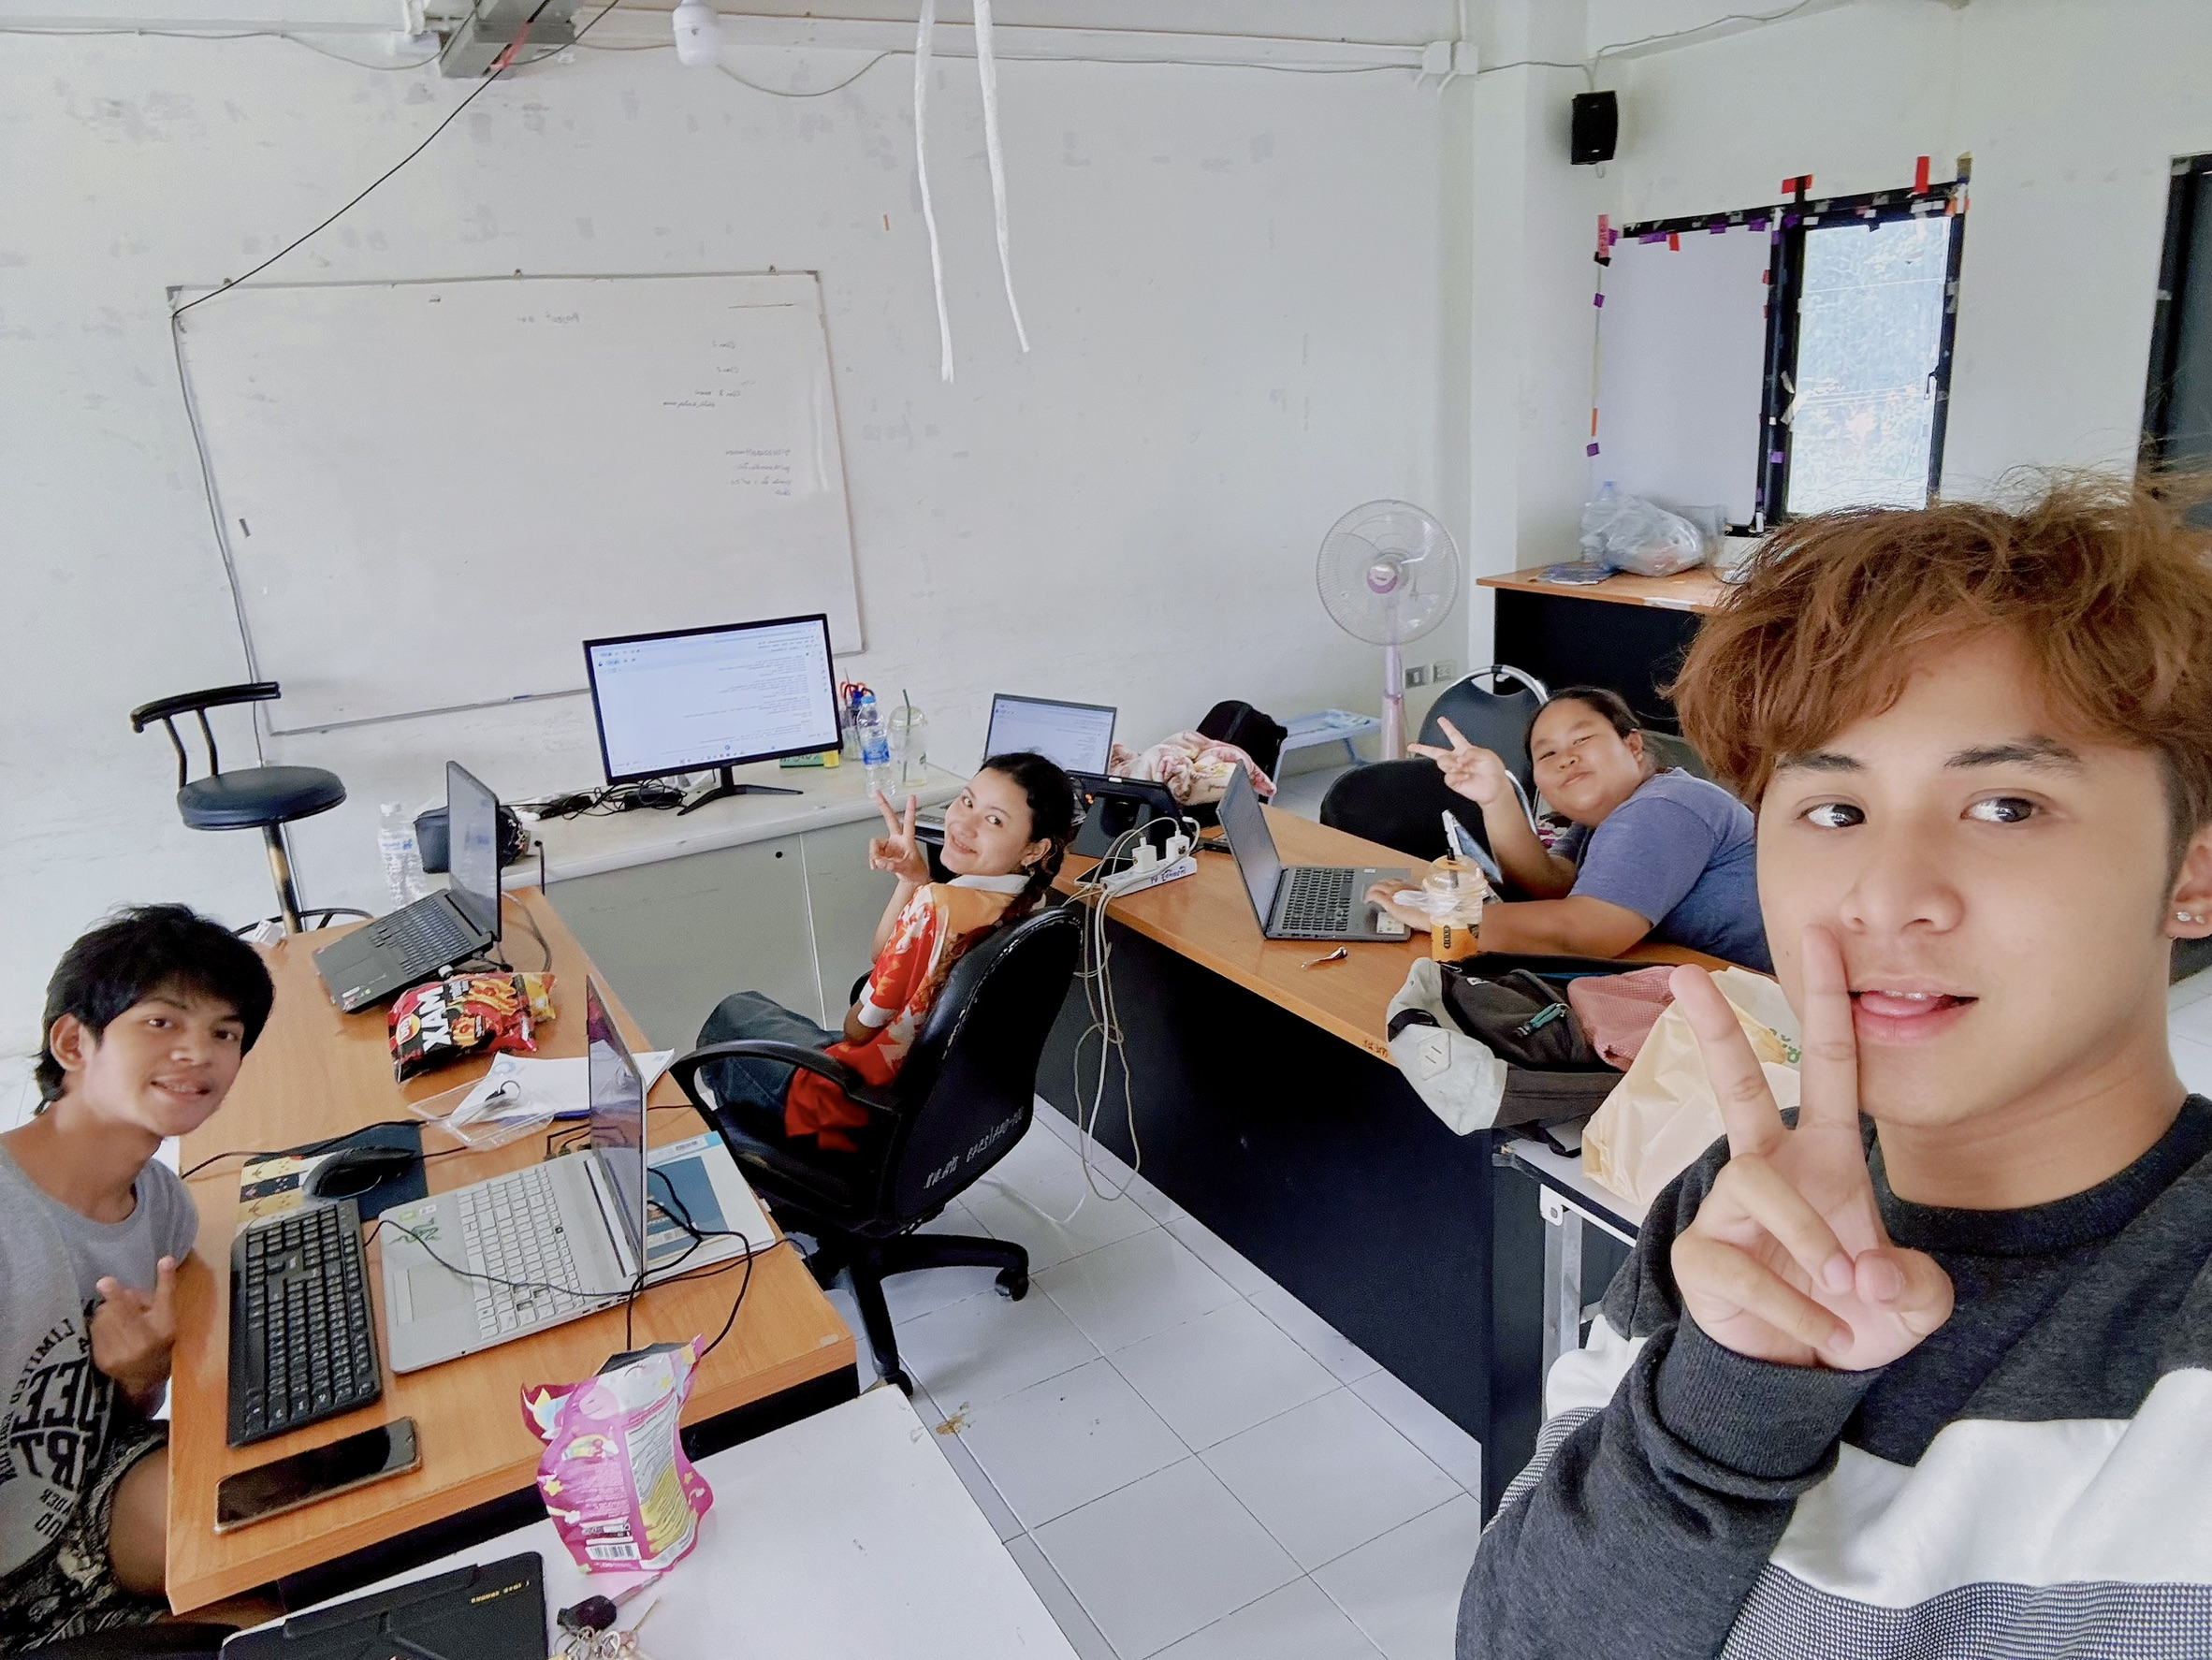


# 🍣 ระบบร้านอาหารญี่ปุ่น (Japanese Restaurant POS Simulation)
### โปรเจกต์จำลองระบบรับออเดอร์ คำนวณราคา และวิเคราะห์ข้อมูล

ในส่วนนี้เราจะสร้าง Class หลัก 3 ตัว ได้แก่ `MenuItem` (เมนู), `Table` (โต๊ะ), และ `Order` (ออเดอร์) เพื่อจำลองการเปิดโต๊ะ สั่งอาหารรวดเดียว แล้วปิดบิลทันที

In [1]:
import random
import time
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib as mpl

# ตั้งค่าฟอนต์ภาษาไทย
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

random.seed(42) # ล็อค seed ไว้ให้สุ่มได้ผลเหมือนเดิมทุกครั้งที่รัน

# --- 1. Class เมนูอาหาร ---
class MenuItem:
    def __init__(self, menu_id, name, price):
        self.menu_id = menu_id
        self.name = name
        self.price = price

# --- 2. Class โต๊ะอาหาร ---
class Table:
    def __init__(self, table_number, num_customers):
        self.table_number = table_number
        self.num_customers = num_customers

# --- 3. Class ออเดอร์ (บิล) ---
class Order:
    def __init__(self, order_id, table):
        self.order_id = order_id
        self.table = table
        self.items = [] # เก็บรายการอาหารที่สั่งในบิลนี้
        self.status = "รับออเดอร์"

    def add_items(self, menu_items_dict):
        """รับ Dictionary ของ {เมนู: จำนวน} เข้ามาในบิล"""
        for menu, qty in menu_items_dict.items():
            self.items.append({'menu': menu, 'qty': qty})

    def calculate_subtotal(self):
        """คำนวณราคารวมก่อน VAT"""
        return sum(item['menu'].price * item['qty'] for item in self.items)

    def calculate_vat(self):
        """คำนวณ VAT 7%"""
        return round(self.calculate_subtotal() * 0.07, 2)

    def calculate_grand_total(self):
        """คำนวณราคาสุทธิ"""
        return self.calculate_subtotal() + self.calculate_vat()

    def close_bill(self):
        """เปลี่ยนสถานะเป็นปิดบิล"""
        self.status = "ปิดบิลแล้ว"

## ส่วนที่ 2: ฟังก์ชันช่วยทำงาน (Helper Functions)
ฟังก์ชันเหล่านี้ใช้สำหรับสุ่มข้อมูลลูกค้า สุ่มเมนูอาหาร และจัดรูปแบบการแสดงผล (มี Default Argument ตามข้อกำหนด)

In [2]:
# ฟังก์ชันที่ 1: สุ่มจำนวนลูกค้า (มี Default Argument)
def random_pax(min_pax=1, max_pax=6):
    """สุ่มจำนวนคนต่อโต๊ะ (ค่าเริ่มต้นคือ 1 ถึง 6 คน)"""
    return random.randint(min_pax, max_pax)

# ฟังก์ชันที่ 2: สุ่มเมนูอาหารและจำนวนจาน
def random_menus(menu_list):
    """สุ่มเมนูที่ลูกค้าสั่ง (1-4 อย่าง) และสุ่มจำนวนจานต่อเมนู (1-3 จาน)"""
    num_menus_to_order = random.randint(1, 4)
    # สุ่มหยิบเมนูไม่ให้ซ้ำกันใน 1 บิล
    chosen_menus = random.sample(menu_list, num_menus_to_order)

    # สร้างเป็น Dictionary คืนค่ากลับไป -> {object_เมนู: จำนวนจาน}
    return {menu: random.randint(1, 3) for menu in chosen_menus}

# ฟังก์ชันที่ 3: จัดรูปแบบสกุลเงิน
def format_currency(amount, symbol="บาท"):
    """จัดรูปแบบตัวเลขให้มีลูกน้ำและจุดทศนิยม"""
    return f"{amount:,.2f} {symbol}"

## ส่วนที่ 3: จำลองการป้อนข้อมูลลูกค้า 350 ออเดอร์
เราจะจำลองเหตุการณ์ลูกค้าเดินเข้ามากินที่ร้าน 350 โต๊ะ (วน Loop) โดยสร้างออบเจกต์ทีละรายการ สั่งอาหารรวดเดียว แล้วปิดบิล

In [3]:
# 1. สร้างรายการเมนูอาหารทั้งหมด 8 เมนูตามที่กำหนด
menu_db = [
    MenuItem("M01", "ข้าวหน้าเนื้อ", 89),
    MenuItem("M02", "ข้าวหน้าหมูทอด", 129),
    MenuItem("M03", "ยากิโซบะ", 99),
    MenuItem("M04", "โชยุราเมน", 99),
    MenuItem("M05", "ไก่ทอดคาราอาเกะ", 139),
    MenuItem("M06", "ข้าวแกงกะหรี่", 89),
    MenuItem("M07", "เกี๊ยวซ่า", 60),
    MenuItem("M08", "ซุปมิโซะ", 30)
]

all_orders = [] # List สำหรับเก็บบิลทั้งหมด

# 2. จำลองรับลูกค้า 350 ออเดอร์
print("⏳ กำลังจำลองระบบรับออเดอร์...")
for i in range(1, 351):
    # สุ่มหมายเลขโต๊ะ (1-8) และจำนวนลูกค้า
    t_num = random.randint(1, 8)
    pax = random_pax(1, 6) # สมมติว่าโต๊ะนึงนั่งได้สูงสุด 6 คน

    # สร้าง Object โต๊ะ
    current_table = Table(table_number=t_num, num_customers=pax)

    # สร้าง Object บิล (Order)
    order = Order(order_id=i, table=current_table)

    # ลูกค้าสั่งอาหาร
    ordered_items = random_menus(menu_db)
    order.add_items(ordered_items)

    # ลูกค้ากินเสร็จ คิดเงิน ปิดบิลทันที
    order.close_bill()

    # เก็บออเดอร์เข้า List
    all_orders.append(order)

print(f"✅ จำลองออเดอร์สำเร็จทั้งหมด {len(all_orders)} รายการ!")

⏳ กำลังจำลองระบบรับออเดอร์...
✅ จำลองออเดอร์สำเร็จทั้งหมด 350 รายการ!


In [4]:
# 3. ส่วนที่เพิ่มเข้ามา: แสดงตัวอย่างบิล 3 ออเดอร์แรก

print("--- 🔍 ตัวอย่างข้อมูลออเดอร์ที่สุ่มได้ (3 รายการแรก) ---")
for order in all_orders[:3]: # ดึงข้อมูลจาก List มาแค่ตำแหน่งที่ 0 ถึง 2 (รวม 3 รายการ)
    print(f"🧾 ออเดอร์ #{order.order_id} | โต๊ะเบอร์: {order.table.table_number} | ลูกค้า: {order.table.num_customers} คน")
    print("   รายการอาหารที่สั่ง:")

    # วนลูปเพื่อแสดงรายการอาหารที่อยู่ในตะกร้า (items) ของบิลนี้
    for item in order.items:
        menu_name = item['menu'].name
        price_per_unit = item['menu'].price
        qty = item['qty']
        total_price = price_per_unit * qty
        print(f"     - {menu_name} (จานละ {price_per_unit} บาท) x {qty} จาน = {total_price} บาท")

    # ดึง Method คำนวณราคามาแสดงผล
    subtotal = order.calculate_subtotal()
    vat = order.calculate_vat()
    grand_total = order.calculate_grand_total()

    print(f"   💰 ยอดรวม: {subtotal} บาท | VAT (7%): {vat} บาท | ยอดสุทธิ: {grand_total} บาท")
    print(f"   📌 สถานะ: {order.status}")
    print("-" * 60)

--- 🔍 ตัวอย่างข้อมูลออเดอร์ที่สุ่มได้ (3 รายการแรก) ---
🧾 ออเดอร์ #1 | โต๊ะเบอร์: 2 | ลูกค้า: 1 คน
   รายการอาหารที่สั่ง:
     - โชยุราเมน (จานละ 99 บาท) x 3 จาน = 297 บาท
     - ข้าวหน้าหมูทอด (จานละ 129 บาท) x 1 จาน = 129 บาท
     - เกี๊ยวซ่า (จานละ 60 บาท) x 3 จาน = 180 บาท
   💰 ยอดรวม: 606 บาท | VAT (7%): 42.42 บาท | ยอดสุทธิ: 648.42 บาท
   📌 สถานะ: ปิดบิลแล้ว
------------------------------------------------------------
🧾 ออเดอร์ #2 | โต๊ะเบอร์: 2 | ลูกค้า: 5 คน
   รายการอาหารที่สั่ง:
     - ข้าวหน้าเนื้อ (จานละ 89 บาท) x 1 จาน = 89 บาท
     - ซุปมิโซะ (จานละ 30 บาท) x 3 จาน = 90 บาท
     - เกี๊ยวซ่า (จานละ 60 บาท) x 3 จาน = 180 บาท
     - ข้าวหน้าหมูทอด (จานละ 129 บาท) x 1 จาน = 129 บาท
   💰 ยอดรวม: 488 บาท | VAT (7%): 34.16 บาท | ยอดสุทธิ: 522.16 บาท
   📌 สถานะ: ปิดบิลแล้ว
------------------------------------------------------------
🧾 ออเดอร์ #3 | โต๊ะเบอร์: 4 | ลูกค้า: 6 คน
   รายการอาหารที่สั่ง:
     - โชยุราเมน (จานละ 99 บาท) x 1 จาน = 99 บาท
     - ซุปมิโซะ (จานละ 30 บาท) x 1

In [5]:
from IPython.core.display import HTML
# ส่วนที่ 4: แปลงข้อมูล บันทึกลง CSV/SQLite และแสดงผลตาราง 350 รายการ

import pandas as pd
import sqlite3
from IPython.display import display

# เตรียมข้อมูลเพื่อบันทึก
orders_db_data = []
order_items_db_data = []

for o in all_orders:
    # 1. ข้อมูลหัวบิล (Master)
    orders_db_data.append({
        "order_id": o.order_id,
        "table_number": o.table.table_number,
        "num_customers": o.table.num_customers,
        "subtotal": o.calculate_subtotal(),
        "vat": o.calculate_vat(),
        "grand_total": o.calculate_grand_total(),
        "status": o.status
    })
    # 2. ข้อมูลรายละเอียดเมนู (Transaction)
    for item in o.items:
        order_items_db_data.append({
            "order_id": o.order_id,
            "menu_name": item['menu'].name,
            "price_per_unit": item['menu'].price,
            "quantity": item['qty'],
            "total_item_price": item['menu'].price * item['qty']
        })

df_orders_db = pd.DataFrame(orders_db_data)
df_items_db = pd.DataFrame(order_items_db_data)

# บันทึกเป็นไฟล์ .csv และ SQLite ตามข้อกำหนด
df_orders_db.to_csv("restaurant_orders.csv", index=False)
df_items_db.to_csv("restaurant_order_items.csv", index=False)

conn = sqlite3.connect("japanese_restaurant.db")
df_orders_db.to_sql("orders", conn, if_exists="replace", index=False)
df_items_db.to_sql("order_items", conn, if_exists="replace", index=False)
print("💾 บันทึกไฟล์ CSV และ SQLite (แยก 2 ตาราง) ")


#สร้างตารางสรุปผล 350 รายการ
summary_display_data = []
for o in all_orders:
    # นำรายการอาหารที่สั่งมาต่อกันเป็นข้อความเดียวให้อ่านจบในบรรทัดเดียว
    items_str = ", ".join([f"{item['menu'].name} (x{item['qty']})" for item in o.items])

    summary_display_data.append({
        "Order ID": o.order_id,
        "โต๊ะ": o.table.table_number,
        "ลูกค้า (คน)": o.table.num_customers,
        "รายการอาหารที่สั่ง": items_str,
        "ยอดรวม": o.calculate_subtotal(),
        "VAT 7%": o.calculate_vat(),
        "ยอดสุทธิ": o.calculate_grand_total()
    })

df_display = pd.DataFrame(summary_display_data)


styled_df = (
    df_display.style
    .format({
        "ยอดรวม": "{:,.2f}",
        "VAT 7%": "{:,.2f}",
        "ยอดสุทธิ": "{:,.2f}"
    })
    .background_gradient(subset=["ยอดสุทธิ"], cmap="Blues")
    .set_properties(**{'text-align': 'left', 'vertical-align': 'middle'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f4f4f4')]}])
)

html_table = styled_df.to_html()

collapsible_html = f"""
<details>
    <summary style="cursor: pointer; font-weight: bold; font-size: 16px; padding: 10px; background-color: #f0f4f8; border-radius: 5px; border: 1px solid #ccc;">
        📑 คลิกเพื่อ ดู/ซ่อน ตารางข้อมูลออเดอร์ทั้งหมด (350 รายการ)
    </summary>
    <div style="margin-top: 10px; max-height: 500px; overflow-y: auto;">
        {html_table}
    </div>
</details>
"""
display(HTML(collapsible_html))

💾 บันทึกไฟล์ CSV และ SQLite (แยก 2 ตาราง) 


,Order ID,โต๊ะ,ลูกค้า (คน),รายการอาหารที่สั่ง,ยอดรวม,VAT 7%,ยอดสุทธิ
0,1,2,1,"โชยุราเมน (x3), ข้าวหน้าหมูทอด (x1), เกี๊ยวซ่า (x3)",606.00,42.42,648.42
1,2,2,5,"ข้าวหน้าเนื้อ (x1), ซุปมิโซะ (x3), เกี๊ยวซ่า (x3), ข้าวหน้าหมูทอด (x1)",488.00,34.16,522.16
2,3,4,6,"โชยุราเมน (x1), ซุปมิโซะ (x1), ไก่ทอดคาราอาเกะ (x3), ยากิโซบะ (x2)",744.00,52.08,796.08
3,4,6,3,"โชยุราเมน (x2), เกี๊ยวซ่า (x1)",258.00,18.06,276.06
4,5,2,4,ข้าวแกงกะหรี่ (x2),178.00,12.46,190.46
5,6,5,1,"ข้าวหน้าหมูทอด (x2), โชยุราเมน (x3), ข้าวหน้าเนื้อ (x3), ไก่ทอดคาราอาเกะ (x2)","1,100.00",77.00,"1,177.00"
6,7,4,6,ข้าวหน้าเนื้อ (x3),267.00,18.69,285.69
7,8,4,3,โชยุราเมน (x1),99.00,6.93,105.93
8,9,7,3,"ข้าวแกงกะหรี่ (x1), ข้าวหน้าหมูทอด (x3), ยากิโซบะ (x2), ซุปมิโซะ (x3)",764.00,53.48,817.48
9,10,2,5,"โชยุราเมน (x2), ข้าวหน้าหมูทอด (x2)",456.00,31.92,487.92


## ส่วนที่ 4: แปลงข้อมูล บันทึกลง CSV และ SQLite
เพื่อทำคะแนน Bonus ในส่วนของ SQL เราจะแยกข้อมูลเป็น 2 ตาราง:
1. `orders_df`: ข้อมูลหัวบิล (โต๊ะ, จำนวนคน, ยอดรวม)
2. `order_items_df`: ข้อมูลรายละเอียดอาหารในบิลแต่ละใบ (สั่งอะไรบ้าง)

In [6]:
# แปลง Object เป็น List of Dictionaries เพื่อทำ Pandas DataFrame
orders_data = []
order_items_data = []

for o in all_orders:
    # 1. ข้อมูลหัวบิล
    orders_data.append({
        "order_id": o.order_id,
        "table_number": o.table.table_number,
        "num_customers": o.table.num_customers,
        "subtotal": o.calculate_subtotal(),
        "vat": o.calculate_vat(),
        "grand_total": o.calculate_grand_total(),
        "status": o.status
    })

    # 2. ข้อมูลรายละเอียดเมนูที่สั่งในบิลนั้น
    for item in o.items:
        order_items_data.append({
            "order_id": o.order_id,
            "menu_name": item['menu'].name,
            "price_per_unit": item['menu'].price,
            "quantity": item['qty'],
            "total_item_price": item['menu'].price * item['qty']
        })

# สร้าง DataFrame
df_orders = pd.DataFrame(orders_data)
df_order_items = pd.DataFrame(order_items_data)

# บันทึกเป็น CSV
df_orders.to_csv("restaurant_orders.csv", index=False)
df_order_items.to_csv("restaurant_order_items.csv", index=False)
print(" บันทึกไฟล์ CSV สำเร็จ!")

# สร้างฐานข้อมูล SQLite และ Insert ข้อมูลลงไป 2 ตาราง
conn = sqlite3.connect("japanese_restaurant.db")
df_orders.to_sql("orders", conn, if_exists="replace", index=False)
df_order_items.to_sql("order_items", conn, if_exists="replace", index=False)
print(" บันทึกข้อมูลลง SQLite (2 ตาราง) ")

 บันทึกไฟล์ CSV สำเร็จ!
 บันทึกข้อมูลลง SQLite (2 ตาราง) 


## ส่วนที่ 5: วิเคราะห์ข้อมูลด้วย Pandas (Data Analysis)
สำรวจข้อมูลเบื้องต้นและตอบคำถามเชิงธุรกิจ (เช่น ยอดขายรวม เมนูขายดี ยอดเฉลี่ยต่อโต๊ะ)

In [7]:
df_analysis = pd.read_csv("restaurant_orders.csv")
df_items_analysis = pd.read_csv("restaurant_order_items.csv")

print("--- ข้อมูลเบื้องต้นของบิล (df.info) ---")
df_analysis.info()

print("\n--- สถิติเบื้องต้น (df.describe) ---")
display(df_analysis.describe())

# 1. สรุปยอดขายรวมทั้งหมดของร้าน
total_revenue = df_analysis['grand_total'].sum()
print(f"\n ยอดขายสุทธิรวม (รวม VAT): {format_currency(total_revenue)}")

# 2. จัดอันดับเมนูขายดี (ดูจากจำนวนจานที่ขายได้ และ รายได้จากเมนูนั้น)
print("\n จัดอันดับเมนูขายดี (เรียงตามรายได้):")
menu_summary = df_items_analysis.groupby('menu_name').agg(
    total_qty=('quantity', 'sum'),
    total_revenue=('total_item_price', 'sum')
).reset_index()

# เรียงลำดับเมนูทำเงินสูงสุด
top_menus = menu_summary.sort_values(by='total_revenue', ascending=False)
display(top_menus)

# 3. วิเคราะห์ยอดลูกค้าต่อโต๊ะ
avg_pax = df_analysis['num_customers'].mean()
avg_bill = df_analysis['grand_total'].mean()
print(f"\n จำนวนลูกค้าเฉลี่ยต่อโต๊ะ: {avg_pax:.1f} คน")
print(f" ยอดใช้จ่ายเฉลี่ยต่อบิล: {format_currency(avg_bill)}")

--- ข้อมูลเบื้องต้นของบิล (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       350 non-null    int64  
 1   table_number   350 non-null    int64  
 2   num_customers  350 non-null    int64  
 3   subtotal       350 non-null    int64  
 4   vat            350 non-null    float64
 5   grand_total    350 non-null    float64
 6   status         350 non-null    object 
dtypes: float64(2), int64(4), object(1)
memory usage: 19.3+ KB

--- สถิติเบื้องต้น (df.describe) ---


,order_id,table_number,num_customers,subtotal,vat,grand_total
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,175.500000,4.634286,3.628571,491.048571,34.373400,525.421971
std,101.180532,2.295622,1.685701,261.468643,18.302805,279.771448
min,1.000000,1.000000,1.000000,30.000000,2.100000,32.100000
25%,88.250000,3.000000,2.000000,277.250000,19.407500,296.657500
50%,175.500000,5.000000,4.000000,476.000000,33.320000,509.320000
75%,262.750000,7.000000,5.000000,685.750000,48.002500,733.752500
max,350.000000,8.000000,6.000000,1180.000000,82.600000,1262.600000



 ยอดขายสุทธิรวม (รวม VAT): 183,897.69 บาท

 จัดอันดับเมนูขายดี (เรียงตามรายได้):


,menu_name,total_qty,total_revenue
0,ข้าวหน้าหมูทอด,257,33153
7,ไก่ทอดคาราอาเกะ,236,32804
4,ยากิโซบะ,248,24552
6,โชยุราเมน,215,21285
1,ข้าวหน้าเนื้อ,229,20381
2,ข้าวแกงกะหรี่,208,18512
5,เกี๊ยวซ่า,224,13440
3,ซุปมิโซะ,258,7740



 จำนวนลูกค้าเฉลี่ยต่อโต๊ะ: 3.6 คน
 ยอดใช้จ่ายเฉลี่ยต่อบิล: 525.42 บาท


## ส่วนที่ 6: วิเคราะห์ข้อมูลด้วย SQL
ฝึกใช้คำสั่ง SQL ขั้นสูงเพื่อดึง Insight ออกมา โดยมีทั้ง WHERE, ORDER BY, GROUP BY และ JOIN

In [8]:
# Query 1: (SELECT, WHERE, ORDER BY) - ขอดูบิลที่มียอดสุทธิเกิน 800 บาท เรียงจากมากไปน้อย
query1 = """
    SELECT order_id, table_number, num_customers, grand_total
    FROM orders
    WHERE grand_total > 800
    ORDER BY grand_total DESC
    LIMIT 5
"""
print("--- ออเดอร์ระดับ VIP (ยอดสูงกว่า 800 บาท) ---")
display(pd.read_sql_query(query1, conn))

# Query 2: (GROUP BY + Aggregate) - โต๊ะเบอร์ไหนทำยอดรวมให้ร้านเยอะที่สุด
query2 = """
    SELECT table_number,
           COUNT(order_id) AS total_bills,
           SUM(grand_total) AS total_revenue
    FROM orders
    GROUP BY table_number
    ORDER BY total_revenue DESC
"""
print("\n--- โต๊ะที่สร้างรายได้สูงสุด (Table Utilization) ---")
display(pd.read_sql_query(query2, conn))

# Query 3: (JOIN) - เอาหัวบิลมารวมกับรายละเอียดเพื่อดูว่า โต๊ะเบอร์ 1 สั่งอะไรไปบ้าง
query3 = """
    SELECT o.order_id, o.table_number, i.menu_name, i.quantity, i.total_item_price
    FROM orders o
    JOIN order_items i ON o.order_id = i.order_id
    WHERE o.table_number = 1
    ORDER BY o.order_id
    LIMIT 10
"""
print("\n--- ประวัติการสั่งอาหารเฉพาะโต๊ะเบอร์ 1 (ใช้ JOIN) ---")
display(pd.read_sql_query(query3, conn))

--- ออเดอร์ระดับ VIP (ยอดสูงกว่า 800 บาท) ---


,order_id,table_number,num_customers,grand_total
0,111,7,4,1262.6
1,255,7,4,1241.2
2,23,3,3,1219.8
3,6,5,1,1177.0
4,184,2,3,1177.0



--- โต๊ะที่สร้างรายได้สูงสุด (Table Utilization) ---


,table_number,total_bills,total_revenue
0,4,50,28855.76
1,7,49,26769.26
2,6,47,26687.94
3,8,47,23248.96
4,3,43,21380.74
5,1,41,20675.61
6,2,38,18645.82
7,5,35,17633.60



--- ประวัติการสั่งอาหารเฉพาะโต๊ะเบอร์ 1 (ใช้ JOIN) ---


,order_id,table_number,menu_name,quantity,total_item_price
0,12,1,ข้าวหน้าหมูทอด,1,129
1,12,1,ข้าวหน้าเนื้อ,2,178
2,12,1,ซุปมิโซะ,3,90
3,12,1,ไก่ทอดคาราอาเกะ,3,417
4,26,1,ข้าวหน้าเนื้อ,2,178
5,30,1,ข้าวหน้าหมูทอด,1,129
6,30,1,ซุปมิโซะ,3,90
7,30,1,เกี๊ยวซ่า,2,120
8,33,1,ยากิโซบะ,2,198
9,33,1,โชยุราเมน,2,198


## ส่วนที่ 7: สร้างกราฟและการนำเสนอ (Data Visualization)
สร้างกราฟ 3 ตัวพร้อม Title, X-label, Y-label เพื่อให้เห็นภาพรวมของธุรกิจ

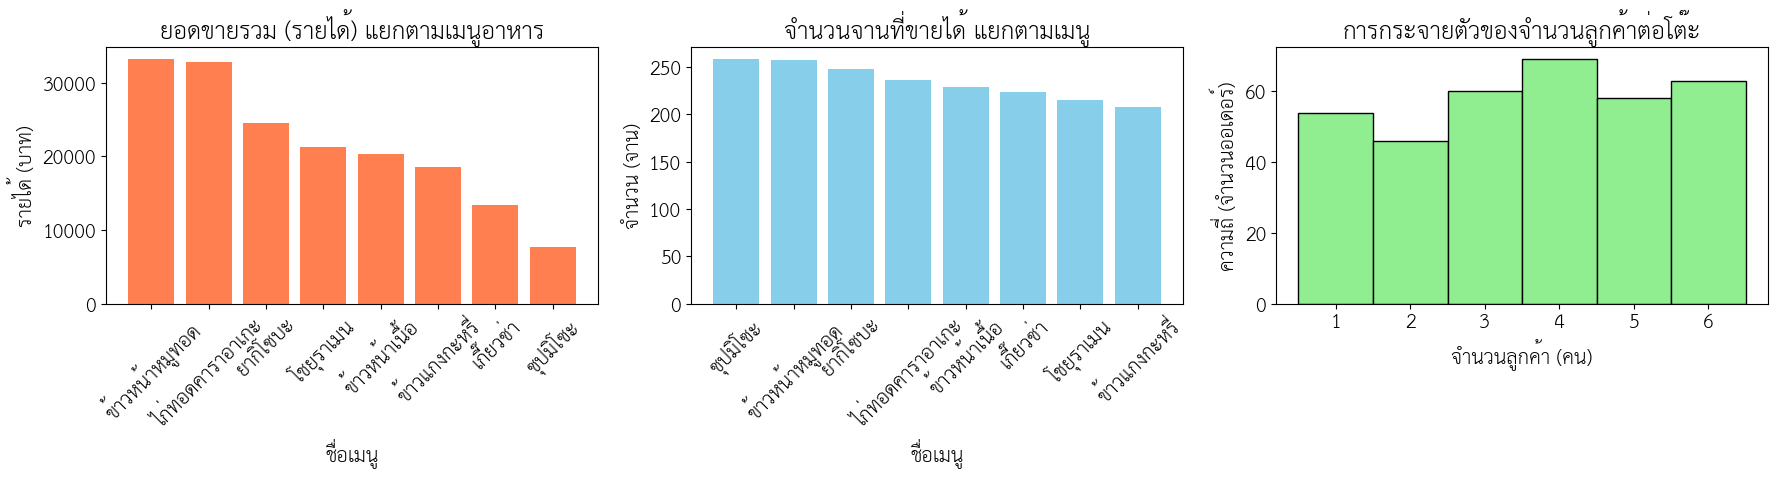

📝 สรุปผลเชิงธุรกิจจากการวิเคราะห์ (Business Insight):
1. เมนูที่ทำรายได้สูงสุดให้กับร้านคือ 'ข้าวหน้าหมูทอด' ควรทำโปรโมชั่นจับคู่เพื่อดันยอดขายเพิ่ม
2. เมนูที่ลูกค้านิยมสั่งเยอะที่สุดในเชิงปริมาณคือ 'ซุปมิโซะ'
3. ลูกค้าส่วนใหญ่ของร้านมักจะมาทานเป็นกลุ่มประมาณ 4 คน การจัดโต๊ะอาหารควรเน้นรองรับลูกค้ากลุ่มขนาดนี้เป็นหลัก


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# กราฟที่ 1: รายได้จำแนกตามเมนูอาหาร (Bar Chart)
axes[0].bar(top_menus['menu_name'], top_menus['total_revenue'], color='coral')
axes[0].set_title('ยอดขายรวม (รายได้) แยกตามเมนูอาหาร')
axes[0].set_xlabel('ชื่อเมนู')
axes[0].set_ylabel('รายได้ (บาท)')
axes[0].tick_params(axis='x', rotation=45)

# กราฟที่ 2: จำนวนจานที่ขายได้จำแนกตามเมนู (Bar Chart)
menu_by_qty = menu_summary.sort_values(by='total_qty', ascending=False)
axes[1].bar(menu_by_qty['menu_name'], menu_by_qty['total_qty'], color='skyblue')
axes[1].set_title('จำนวนจานที่ขายได้ แยกตามเมนู')
axes[1].set_xlabel('ชื่อเมนู')
axes[1].set_ylabel('จำนวน (จาน)')
axes[1].tick_params(axis='x', rotation=45)

# กราฟที่ 3: สัดส่วนลูกค้าที่เข้ามาทาน (Histogram)
axes[2].hist(df_analysis['num_customers'], bins=range(1, 8), align='left', color='lightgreen', edgecolor='black')
axes[2].set_title('การกระจายตัวของจำนวนลูกค้าต่อโต๊ะ')
axes[2].set_xlabel('จำนวนลูกค้า (คน)')
axes[2].set_ylabel('ความถี่ (จำนวนออเดอร์)')

plt.tight_layout()
plt.show()

# พิมพ์สรุปผล
print("📝 สรุปผลเชิงธุรกิจจากการวิเคราะห์ (Business Insight):")
print(f"1. เมนูที่ทำรายได้สูงสุดให้กับร้านคือ '{top_menus.iloc[0]['menu_name']}' ควรทำโปรโมชั่นจับคู่เพื่อดันยอดขายเพิ่ม")
print(f"2. เมนูที่ลูกค้านิยมสั่งเยอะที่สุดในเชิงปริมาณคือ '{menu_by_qty.iloc[0]['menu_name']}'")
print(f"3. ลูกค้าส่วนใหญ่ของร้านมักจะมาทานเป็นกลุ่มประมาณ {df_analysis['num_customers'].mode()[0]} คน การจัดโต๊ะอาหารควรเน้นรองรับลูกค้ากลุ่มขนาดนี้เป็นหลัก")

from IPython.display import HTML, display

# ใส่ ID ของวิดีโอจาก Google Drive
video_id = "19ZCgNJIQUZTn8DY174BkUR4Ii8jgW1O5"
video_url = f"https://drive.google.com/file/d/{video_id}/preview"

# แสดงผลเป็นกรอบวิดีโอ (iframe)
print("▶️ กดเล่นวิดีโอพรีเซนต์ของกลุ่มเราได้เลยครับ:")
display(HTML(f'<iframe src="{video_url}" width="640" height="480" allow="autoplay" allowfullscreen></iframe>'))